# Testing Spatiotemporal Samplers

This notebook contains tests and examples for the new spatiotemporal sampling functionality in TorchGeo:
- `SpatialSampler` - Base class for spatial sampling
- `TemporalSampler` - Base class for temporal sampling  
- `SpatioTemporalGeoSampler` - Combines spatial and temporal samplers

The tests are inspired by the unit tests in `tests/samplers/test_single.py`.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Import required libraries
import math
from collections.abc import Iterator, Sequence
from datetime import datetime, timedelta
from itertools import product

import pandas as pd
import shapely
import torch
from geopandas import GeoDataFrame
from pyproj import CRS
from shapely import Geometry, Point
from torch.utils.data import DataLoader

from torchgeo.datasets import GeoDataset, stack_samples
from torchgeo.datasets.utils import GeoSlice
from torchgeo.samplers import Units
from torchgeo.samplers.single import (
    SpatialSampler,
    TemporalSampler,
    RandomSpatialSampler,
    GridSpatialSampler,
    PreChippedSpatialSampler,
    WindowTemporalSampler,
    FixedLengthTemporalSampler,
    FullTemporalSampler,
    SpatioTemporalGeoSampler,
)

print("Imports successful!")

Imports successful!


## Test Dataset Setup

Create a custom dataset for testing, similar to the unit tests.

In [3]:
# Define test time range
MINT = pd.Timestamp('2023-01-01')
MAXT = pd.Timestamp('2023-12-31')

class CustomGeoDataset(GeoDataset):
    """Custom dataset for testing spatiotemporal samplers."""
    
    def __init__(
        self, 
        geometry: Sequence[Geometry], 
        res: tuple[float, float] = (10, 10),
        time_intervals: list[tuple[pd.Timestamp, pd.Timestamp]] | None = None
    ) -> None:
        # Create time intervals - use default or provided ones
        if time_intervals is None:
            intervals = [(MINT, MAXT)] * len(geometry)
        else:
            intervals = time_intervals
            
        index = pd.IntervalIndex.from_tuples(intervals, closed='both', name='datetime')
        crs = CRS.from_epsg(3005)  # BC Albers projection
        
        # Create filepaths for each geometry/time combination
        filepaths = []
        for i, (geom, interval) in enumerate(zip(geometry, intervals)):
            start_date = interval[0].strftime('%Y%m%d')
            end_date = interval[1].strftime('%Y%m%d')
            filepath = f"test_data_region_{i}_{start_date}_{end_date}.tif"
            filepaths.append(filepath)
        
        self.index = GeoDataFrame(
            data={'filepath': filepaths}, 
            index=index, 
            geometry=geometry, 
            crs=crs
        )
        self.res = res

    def __getitem__(self, query: GeoSlice) -> dict[str, GeoSlice]:
        x, y, t = self._disambiguate_slice(query)
        interval = pd.Interval(t.start, t.stop)
        index = self.index.iloc[self.index.index.overlaps(interval)]
        index = index.iloc[:: t.step]
        index = index.cx[x.start : x.stop, y.start : y.stop]
        
        # Get filepaths for intersecting regions
        filepaths = index['filepath'].tolist() if len(index) > 0 else []
        return {'index': query, 'filepaths': filepaths}

# Create test datasets
print("Creating test datasets...")

# Simple dataset with one large region
simple_geometry = [shapely.box(0, 0, 1000, 1000)]
simple_dataset = CustomGeoDataset(simple_geometry)

# Multi-region dataset
multi_geometry = [
    shapely.box(100, 100, 500, 500),
    shapely.box(600, 600, 1000, 1000),
    shapely.box(200, 200, 400, 400)
]
multi_dataset = CustomGeoDataset(multi_geometry)

# Time-series dataset with multiple time intervals
time_intervals = [
    (pd.Timestamp('2023-01-01'), pd.Timestamp('2023-03-31')),  # Q1
    (pd.Timestamp('2023-04-01'), pd.Timestamp('2023-06-30')),  # Q2
    (pd.Timestamp('2023-07-01'), pd.Timestamp('2023-09-30')),  # Q3
    (pd.Timestamp('2023-10-01'), pd.Timestamp('2023-12-31')),  # Q4
    (pd.Timestamp('2023-05-01'), pd.Timestamp('2023-08-31'))   # New sample: May-Aug
]
timeseries_geometry = [shapely.box(0, 0, 1000, 1000)] * 4 + [shapely.box(1100, 1100, 1500, 1500)]
timeseries_dataset = CustomGeoDataset(timeseries_geometry, time_intervals=time_intervals)

print(f"Simple dataset: {len(simple_dataset.index)} regions")
print(f"Multi dataset: {len(multi_dataset.index)} regions")
print(f"Timeseries dataset: {len(timeseries_dataset.index)} regions")
print(f"Timeseries time range: {timeseries_dataset.index.index.min().left} to {timeseries_dataset.index.index.max().right}")

Creating test datasets...
Converting CustomGeoDataset res from (0.0, 0.0) to (10, 10)
Converting CustomGeoDataset res from (0.0, 0.0) to (10, 10)
Converting CustomGeoDataset res from (0.0, 0.0) to (10, 10)
Simple dataset: 1 regions
Multi dataset: 3 regions
Timeseries dataset: 5 regions
Timeseries time range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00


## Test Spatial Samplers

Test the new spatial sampler classes.

In [4]:
print("=== Testing RandomSpatialSampler ===")

# Test that direct iteration is forbidden
try:
    random_spatial_direct = RandomSpatialSampler(
        dataset=simple_dataset,
        size=100,
        length=5,
        units=Units.CRS
    )
    list(random_spatial_direct)  # This should raise an error
    print("ERROR: Direct iteration should be forbidden!")
except RuntimeError as e:
    print(f"✓ Direct iteration correctly forbidden: {e}")

# Test RandomSpatialSampler through as_spatiotemporal
random_spatial = RandomSpatialSampler.as_spatiotemporal(
    dataset=simple_dataset,
    size=100,  # 100x100 CRS units
    length=5,   # Generate 5 random samples
    units=Units.CRS
)

print(f"RandomSpatialSampler.as_spatiotemporal() length: {len(random_spatial)}")
print(f"Type: {type(random_spatial)}")

# Generate some samples - now returns 3-tuples with temporal dimension
samples = list(random_spatial)
print(f"Generated {len(samples)} spatiotemporal samples:")
for i, (x_slice, y_slice, t_slice) in enumerate(samples[:3]):  # Show first 3
    width = x_slice.stop - x_slice.start
    height = y_slice.stop - y_slice.start
    print(f"  Sample {i+1}: x=[{x_slice.start:.1f}, {x_slice.stop:.1f}], y=[{y_slice.start:.1f}, {y_slice.stop:.1f}], t=[{t_slice.start}, {t_slice.stop}], size=({height:.1f}, {width:.1f})")

print("\n=== Testing GridSpatialSampler ===")

# Test that direct iteration is forbidden
try:
    grid_spatial_direct = GridSpatialSampler(
        dataset=simple_dataset,
        size=200,
        stride=150,
        units=Units.CRS
    )
    list(grid_spatial_direct)  # This should raise an error
    print("ERROR: Direct iteration should be forbidden!")
except RuntimeError as e:
    print(f"✓ Direct iteration correctly forbidden: {e}")

# Test GridSpatialSampler through as_spatiotemporal
grid_spatial = GridSpatialSampler.as_spatiotemporal(
    dataset=simple_dataset,
    size=200,   # 200x200 CRS units
    stride=150, # 150 unit stride (50 unit overlap)
    units=Units.CRS
)

print(f"GridSpatialSampler.as_spatiotemporal() length: {len(grid_spatial)}")
print(f"Type: {type(grid_spatial)}")
print(f"Sample size: {grid_spatial.spatial_sampler.size}")
print(f"Stride: {grid_spatial.spatial_sampler.stride}")

# Show first few grid samples - now returns 3-tuples with temporal dimension
grid_samples = list(grid_spatial)
print(f"Generated {len(grid_samples)} spatiotemporal samples:")
for i, (x_slice, y_slice, t_slice) in enumerate(grid_samples[:5]):  # Show first 5
    width = x_slice.stop - x_slice.start
    height = y_slice.stop - y_slice.start
    print(f"  Sample {i+1}: x=[{x_slice.start:.1f}, {x_slice.stop:.1f}], y=[{y_slice.start:.1f}, {y_slice.stop:.1f}], t=[{t_slice.start}, {t_slice.stop}], size=({height:.1f}, {width:.1f})")

=== Testing RandomSpatialSampler ===
✓ Direct iteration correctly forbidden: Direct iteration over RandomSpatialSampler is not allowed. Use RandomSpatialSampler.as_spatiotemporal() to create a SpatioTemporalGeoSampler instead.
RandomSpatialSampler.as_spatiotemporal() length: 5
Type: <class 'torchgeo.samplers.single.SpatioTemporalGeoSampler'>
Generated 5 spatiotemporal samples:
  Sample 1: x=[710.0, 810.0], y=[290.0, 390.0], t=[2023-01-01 00:00:00, 2023-12-31 00:00:00], size=(100.0, 100.0)
  Sample 2: x=[700.0, 800.0], y=[680.0, 780.0], t=[2023-01-01 00:00:00, 2023-12-31 00:00:00], size=(100.0, 100.0)
  Sample 3: x=[430.0, 530.0], y=[150.0, 250.0], t=[2023-01-01 00:00:00, 2023-12-31 00:00:00], size=(100.0, 100.0)

=== Testing GridSpatialSampler ===
✓ Direct iteration correctly forbidden: Direct iteration over GridSpatialSampler is not allowed. Use GridSpatialSampler.as_spatiotemporal() to create a SpatioTemporalGeoSampler instead.
GridSpatialSampler.as_spatiotemporal() length: 49
Type: 

In [5]:
print("=== Testing PreChippedSpatialSampler ===")

# Test that direct iteration is forbidden
try:
    prechipped_spatial_direct = PreChippedSpatialSampler(
        dataset=multi_dataset,
        shuffle=False
    )
    list(prechipped_spatial_direct)  # This should raise an error
    print("ERROR: Direct iteration should be forbidden!")
except RuntimeError as e:
    print(f"✓ Direct iteration correctly forbidden: {e}")

# Test PreChippedSpatialSampler through as_spatiotemporal
prechipped_spatial = PreChippedSpatialSampler.as_spatiotemporal(
    dataset=multi_dataset,
    shuffle=False
)

print(f"PreChippedSpatialSampler.as_spatiotemporal() length: {len(prechipped_spatial)}")
print(f"Type: {type(prechipped_spatial)}")

# Show all pre-chipped samples - now returns 3-tuples with temporal dimension
prechipped_samples = list(prechipped_spatial)
print(f"Generated {len(prechipped_samples)} spatiotemporal samples:")
for i, (x_slice, y_slice, t_slice) in enumerate(prechipped_samples):
    width = x_slice.stop - x_slice.start
    height = y_slice.stop - y_slice.start
    print(f"  Sample {i+1}: x=[{x_slice.start:.1f}, {x_slice.stop:.1f}], y=[{y_slice.start:.1f}, {y_slice.stop:.1f}], t=[{t_slice.start}, {t_slice.stop}], size=({height:.1f}, {width:.1f})")

# Test with shuffle
print("\n--- Testing with shuffle=True ---")
prechipped_shuffled = PreChippedSpatialSampler.as_spatiotemporal(
    dataset=multi_dataset,
    shuffle=True,
    generator=torch.Generator().manual_seed(42)
)

shuffled_samples = list(prechipped_shuffled)
print("Shuffled order (spatiotemporal samples):")
for i, (x_slice, y_slice, t_slice) in enumerate(shuffled_samples):
    print(f"  Sample {i+1}: x=[{x_slice.start:.1f}, {x_slice.stop:.1f}], y=[{y_slice.start:.1f}, {y_slice.stop:.1f}], t=[{t_slice.start}, {t_slice.stop}]")

=== Testing PreChippedSpatialSampler ===
✓ Direct iteration correctly forbidden: Direct iteration over PreChippedSpatialSampler is not allowed. Use PreChippedSpatialSampler.as_spatiotemporal() to create a SpatioTemporalGeoSampler instead.
PreChippedSpatialSampler.as_spatiotemporal() length: 3
Type: <class 'torchgeo.samplers.single.SpatioTemporalGeoSampler'>
Generated 3 spatiotemporal samples:
  Sample 1: x=[100.0, 500.0], y=[100.0, 500.0], t=[2023-01-01 00:00:00, 2023-12-31 00:00:00], size=(400.0, 400.0)
  Sample 2: x=[600.0, 1000.0], y=[600.0, 1000.0], t=[2023-01-01 00:00:00, 2023-12-31 00:00:00], size=(400.0, 400.0)
  Sample 3: x=[200.0, 400.0], y=[200.0, 400.0], t=[2023-01-01 00:00:00, 2023-12-31 00:00:00], size=(200.0, 200.0)

--- Testing with shuffle=True ---
Shuffled order (spatiotemporal samples):
  Sample 1: x=[100.0, 500.0], y=[100.0, 500.0], t=[2023-01-01 00:00:00, 2023-12-31 00:00:00]
  Sample 2: x=[200.0, 400.0], y=[200.0, 400.0], t=[2023-01-01 00:00:00, 2023-12-31 00:00:00

In [6]:
multi_dataset.index

,filepath,geometry
datetime,,
"[2023-01-01 00:00:00, 2023-12-31 00:00:00]",test_data_region_0_20230101_20231231.tif,"POLYGON ((500 100, 500 500, 100 500, 100 100, ..."
"[2023-01-01 00:00:00, 2023-12-31 00:00:00]",test_data_region_1_20230101_20231231.tif,"POLYGON ((1000 600, 1000 1000, 600 1000, 600 6..."
"[2023-01-01 00:00:00, 2023-12-31 00:00:00]",test_data_region_2_20230101_20231231.tif,"POLYGON ((400 200, 400 400, 200 400, 200 200, ..."


## Test Temporal Samplers

Test the new temporal sampler classes.

In [7]:
print("=== Testing FullTemporalSampler ===")

# Test that direct iteration is forbidden
try:
    full_temporal_direct = FullTemporalSampler(dataset=timeseries_dataset)
    list(full_temporal_direct)  # This should raise an error
    print("ERROR: Direct iteration should be forbidden!")
except RuntimeError as e:
    print(f"✓ Direct iteration correctly forbidden: {e}")

# Test FullTemporalSampler through as_spatiotemporal
full_temporal = FullTemporalSampler.as_spatiotemporal(dataset=timeseries_dataset)

print(f"FullTemporalSampler.as_spatiotemporal() length: {len(full_temporal)}")
print(f"Type: {type(full_temporal)}")

# Get the full temporal sample - now returns 3-tuples with spatial dimension
temporal_samples = list(full_temporal)
print(f"Generated {len(temporal_samples)} spatiotemporal samples:")
for i, (x_slice, y_slice, t_slice) in enumerate(temporal_samples):
    width = x_slice.stop - x_slice.start
    height = y_slice.stop - y_slice.start
    print(f"  Sample {i+1}: x=[{x_slice.start:.1f}, {x_slice.stop:.1f}], y=[{y_slice.start:.1f}, {y_slice.stop:.1f}], t=[{t_slice.start}, {t_slice.stop}], size=({height:.1f}, {width:.1f})")

print("\n=== Testing WindowTemporalSampler ===")

# Test that direct iteration is forbidden
try:
    window_temporal_direct = WindowTemporalSampler(
        dataset=timeseries_dataset,
        window_size=timedelta(days=30),
        stride=timedelta(days=15)
    )
    list(window_temporal_direct)  # This should raise an error
    print("ERROR: Direct iteration should be forbidden!")
except RuntimeError as e:
    print(f"✓ Direct iteration correctly forbidden: {e}")

# Test WindowTemporalSampler through as_spatiotemporal
window_temporal = WindowTemporalSampler.as_spatiotemporal(
    dataset=timeseries_dataset,
    window_size=timedelta(days=30),  # ~1 month windows
    stride=timedelta(days=15)        # 15 day stride (50% overlap)
)

print(f"WindowTemporalSampler.as_spatiotemporal() length: {len(window_temporal)}")
print(f"Type: {type(window_temporal)}")

# Show temporal windows - now returns 3-tuples with spatial dimension
window_samples = list(window_temporal)
print(f"Generated {len(window_samples)} spatiotemporal samples:")
for i, (x_slice, y_slice, t_slice) in enumerate(window_samples[:8]):  # Show first 8
    duration = t_slice.stop - t_slice.start
    width = x_slice.stop - x_slice.start
    height = y_slice.stop - y_slice.start
    print(f"  Sample {i+1}: spatial=({height:.0f}x{width:.0f}), temporal={t_slice.start} to {t_slice.stop} (duration: {duration.days} days)")

print("\n=== Testing FixedLengthTemporalSampler ===")

# Test that direct iteration is forbidden
try:
    fixed_temporal_direct = FixedLengthTemporalSampler(
        dataset=timeseries_dataset,
        length=2,
        stride=1,
        mode='consecutive'
    )
    list(fixed_temporal_direct)  # This should raise an error
    print("ERROR: Direct iteration should be forbidden!")
except RuntimeError as e:
    print(f"✓ Direct iteration correctly forbidden: {e}")

# Test FixedLengthTemporalSampler through as_spatiotemporal
fixed_temporal = FixedLengthTemporalSampler.as_spatiotemporal(
    dataset=timeseries_dataset,
    length=2,  # 2 timestamps per sample
    stride=1,  # Move by 1 timestamp each time
    mode='consecutive'
)

print(f"FixedLengthTemporalSampler.as_spatiotemporal() length: {len(fixed_temporal)}")
print(f"Type: {type(fixed_temporal)}")
print(f"Available timestamps: {len(fixed_temporal.temporal_sampler.timestamps)}")
print(f"Timestamps: {[str(t) for t in fixed_temporal.temporal_sampler.timestamps[:5]]}...")  # Show first 5

# Show fixed-length samples - now returns 3-tuples with spatial dimension
fixed_samples = list(fixed_temporal)
print(f"Generated {len(fixed_samples)} spatiotemporal samples:")
for i, (x_slice, y_slice, t_slice) in enumerate(fixed_samples[:5]):  # Show first 5
    width = x_slice.stop - x_slice.start
    height = y_slice.stop - y_slice.start
    print(f"  Sample {i+1}: spatial=({height:.0f}x{width:.0f}), temporal={t_slice.start} to {t_slice.stop}")

=== Testing FullTemporalSampler ===
✓ Direct iteration correctly forbidden: Direct iteration over FullTemporalSampler is not allowed. Use FullTemporalSampler.as_spatiotemporal() to create a SpatioTemporalGeoSampler instead.
FullTemporalSampler.as_spatiotemporal() length: 1
Type: <class 'torchgeo.samplers.single.SpatioTemporalGeoSampler'>
Generated 1 spatiotemporal samples:
  Sample 1: x=[0.0, 1500.0], y=[0.0, 1500.0], t=[2023-01-01 00:00:00, 2023-12-31 00:00:00], size=(1500.0, 1500.0)

=== Testing WindowTemporalSampler ===
✓ Direct iteration correctly forbidden: Direct iteration over WindowTemporalSampler is not allowed. Use WindowTemporalSampler.as_spatiotemporal() to create a SpatioTemporalGeoSampler instead.
WindowTemporalSampler.as_spatiotemporal() length: 23
Type: <class 'torchgeo.samplers.single.SpatioTemporalGeoSampler'>
Generated 23 spatiotemporal samples:
  Sample 1: spatial=(1500x1500), temporal=2023-01-01 00:00:00 to 2023-01-31 00:00:00 (duration: 30 days)
  Sample 2: spatia

In [8]:
timeseries_dataset.index

,filepath,geometry
datetime,,
"[2023-01-01 00:00:00, 2023-03-31 00:00:00]",test_data_region_0_20230101_20230331.tif,"POLYGON ((1000 0, 1000 1000, 0 1000, 0 0, 1000..."
"[2023-04-01 00:00:00, 2023-06-30 00:00:00]",test_data_region_1_20230401_20230630.tif,"POLYGON ((1000 0, 1000 1000, 0 1000, 0 0, 1000..."
"[2023-07-01 00:00:00, 2023-09-30 00:00:00]",test_data_region_2_20230701_20230930.tif,"POLYGON ((1000 0, 1000 1000, 0 1000, 0 0, 1000..."
"[2023-10-01 00:00:00, 2023-12-31 00:00:00]",test_data_region_3_20231001_20231231.tif,"POLYGON ((1000 0, 1000 1000, 0 1000, 0 0, 1000..."
"[2023-05-01 00:00:00, 2023-08-31 00:00:00]",test_data_region_4_20230501_20230831.tif,"POLYGON ((1500 1100, 1500 1500, 1100 1500, 110..."


## Test SpatioTemporalGeoSampler

Test the main combined spatiotemporal sampler.

In [9]:
print("=== Testing SpatioTemporalGeoSampler (Product Mode) ===")

# Test that direct iteration is forbidden on individual samplers
try:
    spatial_sampler_direct = GridSpatialSampler(
        dataset=timeseries_dataset,
        size=300,
        stride=250,
        units=Units.CRS
    )
    list(spatial_sampler_direct)  # This should raise an error
    print("ERROR: Direct iteration should be forbidden!")
except RuntimeError as e:
    print(f"✓ Direct spatial iteration correctly forbidden: {e}")

try:
    temporal_sampler_direct = WindowTemporalSampler(
        dataset=timeseries_dataset,
        window_size=timedelta(days=60),
        stride=timedelta(days=90)
    )
    list(temporal_sampler_direct)  # This should raise an error
    print("ERROR: Direct iteration should be forbidden!")
except RuntimeError as e:
    print(f"✓ Direct temporal iteration correctly forbidden: {e}")

# Create spatial and temporal samplers for internal use by SpatioTemporalGeoSampler
spatial_sampler = GridSpatialSampler(
    dataset=timeseries_dataset,
    size=600,
    stride=250,
    units=Units.CRS
)

temporal_sampler = WindowTemporalSampler(
    dataset=timeseries_dataset,
    window_size=timedelta(days=60),  # 2 month windows
    stride=timedelta(days=90)        # 3 month stride
)

print(f"Spatial sampler length: {len(spatial_sampler)}")
print(f"Temporal sampler length: {len(temporal_sampler)}")

# Combine them with product mode - SpatioTemporalGeoSampler can access samplers internally
spatiotemporal_product = SpatioTemporalGeoSampler(
    spatial_sampler=spatial_sampler,
    temporal_sampler=temporal_sampler,
    mode='product'
)

print(f"SpatioTemporalGeoSampler (product) length: {len(spatiotemporal_product)}")

# Generate samples
product_samples = list(spatiotemporal_product)
print(f"Generated {len(product_samples)} spatiotemporal samples:")

for i, (x_slice, y_slice, t_slice) in enumerate(product_samples[:8]):  # Show first 8
    spatial_size = (y_slice.stop - y_slice.start, x_slice.stop - x_slice.start)
    temporal_duration = t_slice.stop - t_slice.start
    print(f"  Sample {i+1}: spatial=({y_slice.start:.0f},{x_slice.start:.0f}) size={spatial_size}, temporal={t_slice.start.strftime('%Y-%m-%d')} to {t_slice.stop.strftime('%Y-%m-%d')} ({temporal_duration.days}d)")

print("\n--- Testing as_spatiotemporal() factory methods ---")

# Show equivalent using as_spatiotemporal factory methods
spatial_via_factory = GridSpatialSampler.as_spatiotemporal(
    dataset=timeseries_dataset,
    size=300,
    stride=250,
    units=Units.CRS,
    temporal_sampler=temporal_sampler,
    mode='product'
)

print(f"GridSpatialSampler.as_spatiotemporal() length: {len(spatial_via_factory)}")

factory_samples = list(spatial_via_factory)
print(f"Factory method generated {len(factory_samples)} samples (should match above)")

# Verify they produce the same results
samples_match = len(product_samples) == len(factory_samples)
if samples_match and product_samples:
    first_match = product_samples[0] == factory_samples[0]
    print(f"Sample comparison - same count: {samples_match}, first sample matches: {first_match}")

=== Testing SpatioTemporalGeoSampler (Product Mode) ===
✓ Direct spatial iteration correctly forbidden: Direct iteration over GridSpatialSampler is not allowed. Use GridSpatialSampler.as_spatiotemporal() to create a SpatioTemporalGeoSampler instead.
✓ Direct temporal iteration correctly forbidden: Direct iteration over WindowTemporalSampler is not allowed. Use WindowTemporalSampler.as_spatiotemporal() to create a SpatioTemporalGeoSampler instead.
Spatial sampler length: 36
Temporal sampler length: 4
SpatioTemporalGeoSampler (product) length: 144
Generated 144 spatiotemporal samples:
  Sample 1: spatial=(0,0) size=(600.0, 600.0), temporal=2023-01-01 to 2023-03-02 (60d)
  Sample 2: spatial=(0,250) size=(600.0, 600.0), temporal=2023-01-01 to 2023-03-02 (60d)
  Sample 3: spatial=(0,500) size=(600.0, 600.0), temporal=2023-01-01 to 2023-03-02 (60d)
  Sample 4: spatial=(250,0) size=(600.0, 600.0), temporal=2023-01-01 to 2023-03-02 (60d)
  Sample 5: spatial=(250,250) size=(600.0, 600.0), tempo

In [10]:
spatiotemporal_product.samples

,x_slice,y_slice,t_slice,geometry
0,"slice(0.0, 600.0, None)","slice(0.0, 600.0, None)","slice(Timestamp('2023-01-01 00:00:00'), Timest...","POLYGON ((600 0, 600 600, 0 600, 0 0, 600 0))"
1,"slice(250.0, 850.0, None)","slice(0.0, 600.0, None)","slice(Timestamp('2023-01-01 00:00:00'), Timest...","POLYGON ((850 0, 850 600, 250 600, 250 0, 850 0))"
2,"slice(500.0, 1100.0, None)","slice(0.0, 600.0, None)","slice(Timestamp('2023-01-01 00:00:00'), Timest...","POLYGON ((1100 0, 1100 600, 500 600, 500 0, 11..."
3,"slice(0.0, 600.0, None)","slice(250.0, 850.0, None)","slice(Timestamp('2023-01-01 00:00:00'), Timest...","POLYGON ((600 250, 600 850, 0 850, 0 250, 600 ..."
4,"slice(250.0, 850.0, None)","slice(250.0, 850.0, None)","slice(Timestamp('2023-01-01 00:00:00'), Timest...","POLYGON ((850 250, 850 850, 250 850, 250 250, ..."
...,...,...,...,...
139,"slice(250.0, 850.0, None)","slice(250.0, 850.0, None)","slice(Timestamp('2023-09-28 00:00:00'), Timest...","POLYGON ((850 250, 850 850, 250 850, 250 250, ..."
140,"slice(500.0, 1100.0, None)","slice(250.0, 850.0, None)","slice(Timestamp('2023-09-28 00:00:00'), Timest...","POLYGON ((1100 250, 1100 850, 500 850, 500 250..."
141,"slice(0.0, 600.0, None)","slice(500.0, 1100.0, None)","slice(Timestamp('2023-09-28 00:00:00'), Timest...","POLYGON ((600 500, 600 1100, 0 1100, 0 500, 60..."
142,"slice(250.0, 850.0, None)","slice(500.0, 1100.0, None)","slice(Timestamp('2023-09-28 00:00:00'), Timest...","POLYGON ((850 500, 850 1100, 250 1100, 250 500..."


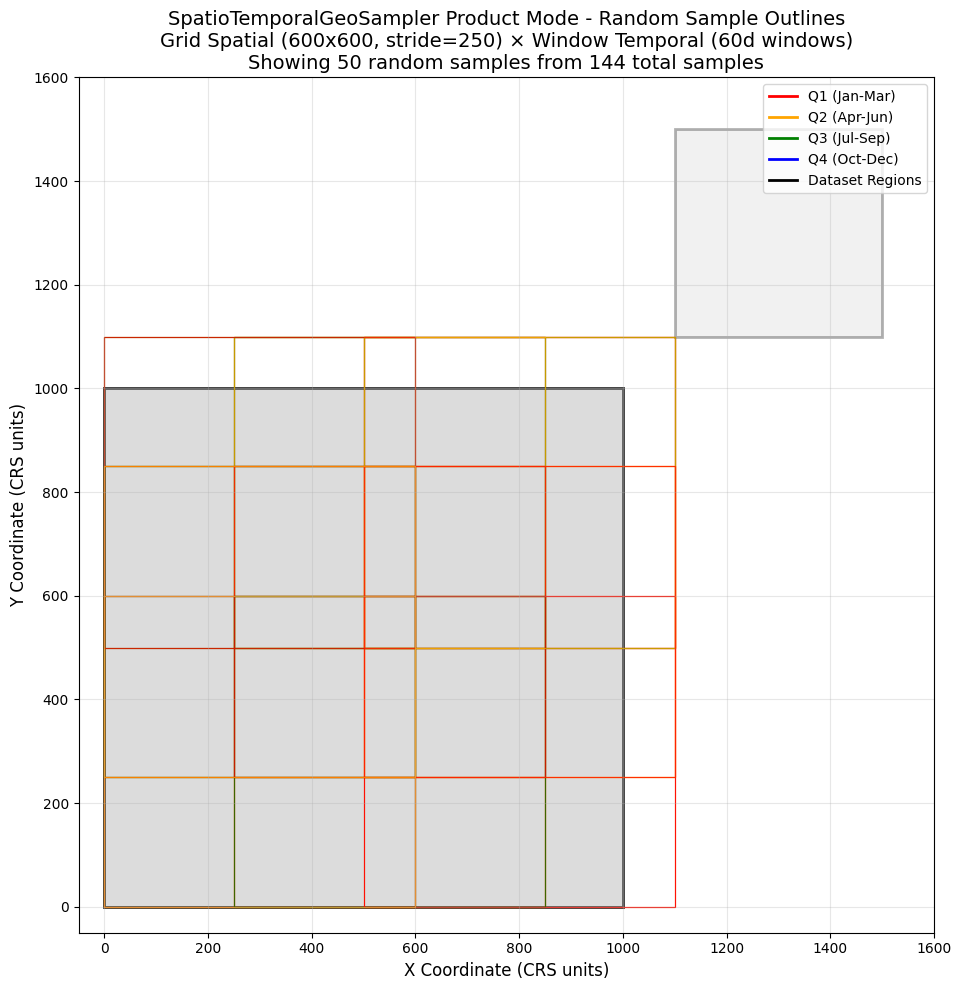

Plotted 50 randomly selected sample outlines from 144 total samples
Spatial grid: 36 positions × Temporal windows: 4 = 144 combinations

Details of first 5 random samples:
  Sample 1: spatial=(0,250) size=(600.0, 600.0), temporal=2023-01-01 to 2023-03-02 (60d)
  Sample 2: spatial=(500,0) size=(600.0, 600.0), temporal=2023-01-01 to 2023-03-02 (60d)
  Sample 3: spatial=(500,250) size=(600.0, 600.0), temporal=2023-04-01 to 2023-05-31 (60d)
  Sample 4: spatial=(500,500) size=(600.0, 600.0), temporal=2023-04-01 to 2023-05-31 (60d)
  Sample 5: spatial=(250,0) size=(600.0, 600.0), temporal=2023-04-01 to 2023-05-31 (60d)


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import PatchCollection
from matplotlib.lines import Line2D
import random

# Set random seed for reproducibility
random.seed(42)

# Create a figure to visualize the spatiotemporal samples
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot the dataset boundaries first
for i, geom in enumerate(timeseries_dataset.index.geometry):
    bounds = geom.bounds
    rect = patches.Rectangle((bounds[0], bounds[1]), 
                           bounds[2] - bounds[0], 
                           bounds[3] - bounds[1],
                           linewidth=2, edgecolor='black', 
                           facecolor='lightgray', alpha=0.3,
                           label=f'Dataset region {i+1}' if i < 3 else '')
    ax.add_patch(rect)

# Randomly sample 50 samples from all product samples
n_samples_to_show = min(50, len(product_samples))
random_indices = random.sample(range(len(product_samples)), n_samples_to_show)
random_samples = [product_samples[i] for i in random_indices]

# Plot the randomly selected spatiotemporal samples as outlines
patch_list = []
colors = []

for i, (x_slice, y_slice, t_slice) in enumerate(random_samples):
    # Create rectangle for each sample
    rect = patches.Rectangle((x_slice.start, y_slice.start), 
                           x_slice.stop - x_slice.start, 
                           y_slice.stop - y_slice.start,
                           linewidth=0.8, 
                           facecolor='none')  # No fill, outline only
    patch_list.append(rect)
    
    # Color by temporal window (different colors for different time periods)
    if t_slice.start.month <= 3:
        colors.append('red')      # Q1
    elif t_slice.start.month <= 6:
        colors.append('orange')   # Q2  
    elif t_slice.start.month <= 9:
        colors.append('green')    # Q3
    else:
        colors.append('blue')     # Q4

# Add all sample patches to the plot
collection = PatchCollection(patch_list, facecolors='none', 
                           edgecolors=colors, linewidths=0.8, alpha=0.7)
ax.add_collection(collection)

# Customize the plot
ax.set_xlim(-50, 1600)
ax.set_ylim(-50, 1600) 
ax.set_xlabel('X Coordinate (CRS units)', fontsize=12)
ax.set_ylabel('Y Coordinate (CRS units)', fontsize=12)
ax.set_title('SpatioTemporalGeoSampler Product Mode - Random Sample Outlines\n' + 
            f'Grid Spatial (600x600, stride=250) × Window Temporal (60d windows)\n' +
            f'Showing {n_samples_to_show} random samples from {len(product_samples)} total samples',
            fontsize=14)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# Add legend for temporal periods
legend_elements = [
    Line2D([0], [0], color='red', lw=2, label='Q1 (Jan-Mar)'),
    Line2D([0], [0], color='orange', lw=2, label='Q2 (Apr-Jun)'), 
    Line2D([0], [0], color='green', lw=2, label='Q3 (Jul-Sep)'),
    Line2D([0], [0], color='blue', lw=2, label='Q4 (Oct-Dec)'),
    Line2D([0], [0], color='black', lw=2, label='Dataset Regions'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Plotted {n_samples_to_show} randomly selected sample outlines from {len(product_samples)} total samples")
print(f"Spatial grid: {len(spatial_sampler)} positions × Temporal windows: {len(temporal_sampler)} = {len(product_samples)} combinations")

# Show some details about the random samples
print(f"\nDetails of first 5 random samples:")
for i, (x_slice, y_slice, t_slice) in enumerate(random_samples[:5]):
    spatial_size = (y_slice.stop - y_slice.start, x_slice.stop - x_slice.start)
    temporal_duration = t_slice.stop - t_slice.start
    print(f"  Sample {i+1}: spatial=({y_slice.start:.0f},{x_slice.start:.0f}) size={spatial_size}, temporal={t_slice.start.strftime('%Y-%m-%d')} to {t_slice.stop.strftime('%Y-%m-%d')} ({temporal_duration.days}d)")

In [12]:
print("=== Testing SpatioTemporalGeoSampler (Zip Mode) ===")

# Create samplers with matching lengths for zip mode
# Note: We create them normally but only SpatioTemporalGeoSampler can iterate over them
random_spatial_zip = RandomSpatialSampler(
    dataset=timeseries_dataset,
    size=200,
    length=5,  # Match temporal sampler length
    units=Units.CRS,
    generator=torch.Generator().manual_seed(42)
)

fixed_temporal_zip = FixedLengthTemporalSampler(
    dataset=timeseries_dataset,
    length=1,  # Single timestamp per sample
    stride=1,
    mode='consecutive'
)

print(f"Random spatial sampler length: {len(random_spatial_zip)}")
print(f"Fixed temporal sampler length: {len(fixed_temporal_zip)}")

# Test that direct iteration is still forbidden
try:
    list(random_spatial_zip)
    print("ERROR: Direct iteration should be forbidden!")
except RuntimeError as e:
    print(f"✓ Direct spatial iteration correctly forbidden: {e}")

try:
    list(fixed_temporal_zip)
    print("ERROR: Direct iteration should be forbidden!")
except RuntimeError as e:
    print(f"✓ Direct temporal iteration correctly forbidden: {e}")

# Create a subset temporal sampler by using the first 5 samples from fixed_temporal_zip
# We need to access _iter_impl directly (which SpatioTemporalGeoSampler can do)
class LimitedTemporalSampler(TemporalSampler):
    def __init__(self, base_sampler, limit):
        super().__init__(base_sampler.dataset, base_sampler.toi)
        self.base_sampler = base_sampler
        self.limit = limit
    
    def __iter__(self):
        raise RuntimeError("Direct iteration not allowed - use through SpatioTemporalGeoSampler")
    
    def _iter_impl(self):
        count = 0
        for sample in self.base_sampler._iter_impl():
            if count >= self.limit:
                break
            yield sample
            count += 1
    
    def __len__(self):
        return min(self.limit, len(self.base_sampler))

limited_temporal = LimitedTemporalSampler(fixed_temporal_zip, 5)
print(f"Limited temporal sampler length: {len(limited_temporal)}")

# Combine with zip mode
spatiotemporal_zip = SpatioTemporalGeoSampler(
    spatial_sampler=random_spatial_zip,
    temporal_sampler=limited_temporal,
    mode='zip'
)

print(f"SpatioTemporalGeoSampler (zip) length: {len(spatiotemporal_zip)}")

# Generate zip samples
zip_samples = list(spatiotemporal_zip)
print(f"Generated {len(zip_samples)} paired spatiotemporal samples:")

for i, (x_slice, y_slice, t_slice) in enumerate(zip_samples):
    spatial_size = (y_slice.stop - y_slice.start, x_slice.stop - x_slice.start)
    temporal_duration = t_slice.stop - t_slice.start
    print(f"  Pair {i+1}: spatial=({y_slice.start:.0f},{x_slice.start:.0f}) size={spatial_size}, temporal={t_slice.start.strftime('%Y-%m-%d')} to {t_slice.stop.strftime('%Y-%m-%d')} ({temporal_duration.days}d)")

print("\n--- Testing factory method for zip mode ---")

# Show using factory method approach
zip_via_factory = RandomSpatialSampler.as_spatiotemporal(
    dataset=timeseries_dataset,
    size=200,
    length=5,
    units=Units.CRS,
    generator=torch.Generator().manual_seed(42),
    temporal_sampler=limited_temporal,
    mode='zip'
)

print(f"Factory method zip sampler length: {len(zip_via_factory)}")
factory_zip_samples = list(zip_via_factory)
print(f"Factory zip method generated {len(factory_zip_samples)} samples")

=== Testing SpatioTemporalGeoSampler (Zip Mode) ===
Random spatial sampler length: 5
Fixed temporal sampler length: 5
✓ Direct spatial iteration correctly forbidden: Direct iteration over RandomSpatialSampler is not allowed. Use RandomSpatialSampler.as_spatiotemporal() to create a SpatioTemporalGeoSampler instead.
✓ Direct temporal iteration correctly forbidden: Direct iteration over FixedLengthTemporalSampler is not allowed. Use FixedLengthTemporalSampler.as_spatiotemporal() to create a SpatioTemporalGeoSampler instead.
Limited temporal sampler length: 5
SpatioTemporalGeoSampler (zip) length: 5
Generated 1 paired spatiotemporal samples:
  Pair 1: spatial=(480,310) size=(200.0, 200.0), temporal=2023-08-31 to 2023-08-31 (0d)

--- Testing factory method for zip mode ---
Factory method zip sampler length: 5
Factory zip method generated 1 samples


## Test Region of Interest (ROI) and Time of Interest (TOI)

Test spatial and temporal filtering.

In [13]:
print("=== Testing ROI and TOI Filtering ===")

# Define ROI (region of interest) - smaller area
roi = shapely.box(100, 100, 400, 400)
print(f"ROI bounds: {roi.bounds}")

# Define TOI (time of interest) - summer months
toi = pd.Interval(
    pd.Timestamp('2023-06-01'), 
    pd.Timestamp('2023-08-31'),
    closed='both'
)
print(f"TOI: {toi.left} to {toi.right}")

# Test that direct iteration is forbidden on filtered samplers
try:
    roi_spatial_direct = RandomSpatialSampler(
        dataset=timeseries_dataset,
        size=50,
        length=5,
        roi=roi,
        units=Units.CRS
    )
    list(roi_spatial_direct)  # This should raise an error
    print("ERROR: Direct iteration should be forbidden!")
except RuntimeError as e:
    print(f"✓ Direct ROI-filtered spatial iteration correctly forbidden: {e}")

try:
    toi_temporal_direct = WindowTemporalSampler(
        dataset=timeseries_dataset,
        window_size=timedelta(days=30),
        toi=toi
    )
    list(toi_temporal_direct)  # This should raise an error
    print("ERROR: Direct iteration should be forbidden!")
except RuntimeError as e:
    print(f"✓ Direct TOI-filtered temporal iteration correctly forbidden: {e}")

# Create filtered samplers for internal use
roi_spatial = RandomSpatialSampler(
    dataset=timeseries_dataset,
    size=50,
    length=5,
    roi=roi,
    units=Units.CRS
)

toi_temporal = WindowTemporalSampler(
    dataset=timeseries_dataset,
    window_size=timedelta(days=30),
    toi=toi
)

print(f"ROI-filtered spatial sampler length: {len(roi_spatial)}")
print(f"TOI-filtered temporal sampler length: {len(toi_temporal)}")

# Test using factory methods with filtering
roi_spatial_via_factory = RandomSpatialSampler.as_spatiotemporal(
    dataset=timeseries_dataset,
    size=50,
    length=5,
    roi=roi,
    units=Units.CRS,
    temporal_sampler=None  # Will use FullTemporalSampler by default
)

print("\nSpatial samples via factory (should be within ROI, full temporal extent):")
roi_factory_samples = list(roi_spatial_via_factory)
for i, (x_slice, y_slice, t_slice) in enumerate(roi_factory_samples[:3]):  # Show first 3
    sample_box = shapely.box(x_slice.start, y_slice.start, x_slice.stop, y_slice.stop)
    within_roi = roi.contains(sample_box) or roi.intersects(sample_box)
    print(f"  Sample {i+1}: [{x_slice.start:.0f}-{x_slice.stop:.0f}, {y_slice.start:.0f}-{y_slice.stop:.0f}] within/intersects_roi={within_roi}, t=[{t_slice.start}, {t_slice.stop}]")

# Test temporal filtering via factory
toi_temporal_via_factory = WindowTemporalSampler.as_spatiotemporal(
    dataset=timeseries_dataset,
    window_size=timedelta(days=30),
    toi=toi,
    spatial_sampler=None  # Will use FullSpatialSampler by default
)

print("\nTemporal samples via factory (should overlap with TOI, full spatial extent):")
toi_factory_samples = list(toi_temporal_via_factory)
for i, (x_slice, y_slice, t_slice) in enumerate(toi_factory_samples[:3]):  # Show first 3
    sample_interval = pd.Interval(t_slice.start, t_slice.stop)
    overlaps_toi = toi.overlaps(sample_interval)
    spatial_size = (y_slice.stop - y_slice.start, x_slice.stop - x_slice.start)
    print(f"  Sample {i+1}: spatial_size={spatial_size} temporal={t_slice.start.strftime('%Y-%m-%d')} to {t_slice.stop.strftime('%Y-%m-%d')} overlaps_toi={overlaps_toi}")

# Combine filtered samplers using SpatioTemporalGeoSampler
filtered_spatiotemporal = SpatioTemporalGeoSampler(
    spatial_sampler=roi_spatial,
    temporal_sampler=toi_temporal,
    mode='product'
)

print(f"\nFiltered SpatioTemporalGeoSampler length: {len(filtered_spatiotemporal)}")

# Show some filtered samples
filtered_samples = list(filtered_spatiotemporal)
print(f"Generated {len(filtered_samples)} filtered spatiotemporal samples:")
for i, (x_slice, y_slice, t_slice) in enumerate(filtered_samples[:3]):
    spatial_box = shapely.box(x_slice.start, y_slice.start, x_slice.stop, y_slice.stop)
    temporal_interval = pd.Interval(t_slice.start, t_slice.stop)
    within_roi = roi.contains(spatial_box) or roi.intersects(spatial_box)
    overlaps_toi = toi.overlaps(temporal_interval)
    print(f"  Sample {i+1}: spatial=[{x_slice.start:.0f}-{x_slice.stop:.0f}, {y_slice.start:.0f}-{y_slice.stop:.0f}] (roi={within_roi}) temporal={t_slice.start.strftime('%m-%d')} to {t_slice.stop.strftime('%m-%d')} (toi={overlaps_toi})")

=== Testing ROI and TOI Filtering ===
ROI bounds: (100.0, 100.0, 400.0, 400.0)
TOI: 2023-06-01 00:00:00 to 2023-08-31 00:00:00
✓ Direct ROI-filtered spatial iteration correctly forbidden: Direct iteration over RandomSpatialSampler is not allowed. Use RandomSpatialSampler.as_spatiotemporal() to create a SpatioTemporalGeoSampler instead.
✓ Direct TOI-filtered temporal iteration correctly forbidden: Direct iteration over WindowTemporalSampler is not allowed. Use WindowTemporalSampler.as_spatiotemporal() to create a SpatioTemporalGeoSampler instead.
ROI-filtered spatial sampler length: 5
TOI-filtered temporal sampler length: 3

Spatial samples via factory (should be within ROI, full temporal extent):
  Sample 1: [310-360, 230-280] within/intersects_roi=True, t=[2023-01-01 00:00:00, 2023-12-31 00:00:00]
  Sample 2: [120-170, 180-230] within/intersects_roi=True, t=[2023-01-01 00:00:00, 2023-12-31 00:00:00]
  Sample 3: [330-380, 230-280] within/intersects_roi=True, t=[2023-01-01 00:00:00, 202

## Test Integration with DataLoader

Test that the samplers work properly with PyTorch DataLoader.

In [14]:
print("=== Testing DataLoader Integration ===")

# Test that direct iteration is forbidden on individual samplers used in DataLoader
try:
    simple_spatial_direct = RandomSpatialSampler(
        dataset=simple_dataset,
        size=100,
        length=3,
        units=Units.CRS,
        generator=torch.Generator().manual_seed(42)
    )
    list(simple_spatial_direct)  # This should raise an error
    print("ERROR: Direct iteration should be forbidden!")
except RuntimeError as e:
    print(f"✓ Direct iteration correctly forbidden: {e}")

# Create samplers for DataLoader testing (can't iterate directly)
simple_spatial = RandomSpatialSampler(
    dataset=simple_dataset,
    size=100,
    length=3,
    units=Units.CRS,
    generator=torch.Generator().manual_seed(42)
)

simple_temporal = FullTemporalSampler(dataset=simple_dataset)

# Only SpatioTemporalGeoSampler can iterate over the individual samplers
dataloader_sampler = SpatioTemporalGeoSampler(
    spatial_sampler=simple_spatial,
    temporal_sampler=simple_temporal,
    mode='product'
)

print(f"DataLoader sampler length: {len(dataloader_sampler)}")

# Verify the sampler works by iterating
test_samples = list(dataloader_sampler)
print(f"Generated {len(test_samples)} samples for DataLoader")

# Create DataLoader
dataloader = DataLoader(
    simple_dataset,
    sampler=dataloader_sampler,
    batch_size=2,
    collate_fn=stack_samples
)

print(f"DataLoader created with batch_size=2")

# Test iteration through DataLoader
print("\nIterating through DataLoader:")
for batch_idx, batch in enumerate(dataloader):
    print(f"  Batch {batch_idx + 1}: {type(batch)} with {len(batch['index'])} samples")
    
    # Show details of first sample in batch
    first_sample = batch['index'][0]
    x_slice, y_slice, t_slice = first_sample
    print(f"    First sample: x=[{x_slice.start:.0f}, {x_slice.stop:.0f}], y=[{y_slice.start:.0f}, {y_slice.stop:.0f}], t=[{t_slice.start}, {t_slice.stop}]")

print("\n--- Testing factory method with DataLoader ---")

# Show equivalent using factory method
dataloader_sampler_factory = RandomSpatialSampler.as_spatiotemporal(
    dataset=simple_dataset,
    size=100,
    length=3,
    units=Units.CRS,
    generator=torch.Generator().manual_seed(42),
    mode='product'
)

print(f"Factory method sampler length: {len(dataloader_sampler_factory)}")

# Create DataLoader with factory-created sampler
dataloader_factory = DataLoader(
    simple_dataset,
    sampler=dataloader_sampler_factory,
    batch_size=2,
    collate_fn=stack_samples
)

print("Iterating through factory-method DataLoader:")
for batch_idx, batch in enumerate(dataloader_factory):
    print(f"  Batch {batch_idx + 1}: {len(batch['index'])} samples")
    if batch_idx == 0:  # Just show first batch
        first_sample = batch['index'][0]
        x_slice, y_slice, t_slice = first_sample
        print(f"    First sample: x=[{x_slice.start:.0f}, {x_slice.stop:.0f}], y=[{y_slice.start:.0f}, {y_slice.stop:.0f}], t=[{t_slice.start}, {t_slice.stop}]")

print("\nDataLoader integration test completed successfully!")

=== Testing DataLoader Integration ===
✓ Direct iteration correctly forbidden: Direct iteration over RandomSpatialSampler is not allowed. Use RandomSpatialSampler.as_spatiotemporal() to create a SpatioTemporalGeoSampler instead.
DataLoader sampler length: 3
Generated 3 samples for DataLoader
DataLoader created with batch_size=2

Iterating through DataLoader:
  Batch 1: <class 'dict'> with 2 samples
    First sample: x=[790, 890], y=[820, 920], t=[2023-01-01 00:00:00, 2023-12-31 00:00:00]
  Batch 2: <class 'dict'> with 1 samples
    First sample: x=[350, 450], y=[540, 640], t=[2023-01-01 00:00:00, 2023-12-31 00:00:00]

--- Testing factory method with DataLoader ---
Factory method sampler length: 3
Iterating through factory-method DataLoader:
  Batch 1: 2 samples
    First sample: x=[790, 890], y=[820, 920], t=[2023-01-01 00:00:00, 2023-12-31 00:00:00]
  Batch 2: 1 samples

DataLoader integration test completed successfully!


## Performance and Edge Case Tests

Test various edge cases and performance considerations.

In [15]:
print("=== Testing Edge Cases ===")

# Test with small areas
print("\n1. Testing small area dataset:")
small_geometry = [shapely.box(0, 0, 50, 50)]
small_dataset = CustomGeoDataset(small_geometry, res=(1, 1))

# Test that direct iteration is forbidden
try:
    small_spatial_direct = RandomSpatialSampler(
        dataset=small_dataset,
        size=10,
        length=3,
        units=Units.CRS
    )
    list(small_spatial_direct)
    print("ERROR: Direct iteration should be forbidden!")
except RuntimeError as e:
    print(f"✓ Direct iteration correctly forbidden: {e}")

# Use factory method for small area testing
small_spatial = RandomSpatialSampler.as_spatiotemporal(
    dataset=small_dataset,
    size=10,
    length=3,
    units=Units.CRS
)

print(f"Small area sampler length: {len(small_spatial)}")
small_samples = list(small_spatial)
for i, (x_slice, y_slice, t_slice) in enumerate(small_samples):
    print(f"  Sample {i+1}: [{x_slice.start:.0f}-{x_slice.stop:.0f}, {y_slice.start:.0f}-{y_slice.stop:.0f}], t=[{t_slice.start}, {t_slice.stop}]")

# Test with point data
print("\n2. Testing point geometry dataset:")
point_geometry = [Point(100, 100), Point(200, 200)]
point_dataset = CustomGeoDataset(point_geometry)

try:
    # Test direct iteration forbidden first
    try:
        point_spatial_direct = RandomSpatialSampler(
            dataset=point_dataset,
            size=0,
            length=2,
            units=Units.CRS
        )
        list(point_spatial_direct)
        print("ERROR: Direct iteration should be forbidden!")
    except RuntimeError as e:
        print(f"✓ Direct iteration correctly forbidden: {e}")
    
    # Test via factory method
    point_spatial = RandomSpatialSampler.as_spatiotemporal(
        dataset=point_dataset,
        size=0,  # Zero size for points
        length=2,
        units=Units.CRS
    )
    print(f"Point dataset sampler length: {len(point_spatial)}")
    point_samples = list(point_spatial)
    for i, (x_slice, y_slice, t_slice) in enumerate(point_samples):
        print(f"  Point sample {i+1}: [{x_slice.start:.0f}-{x_slice.stop:.0f}, {y_slice.start:.0f}-{y_slice.stop:.0f}], t=[{t_slice.start}, {t_slice.stop}]")
except Exception as e:
    print(f"  Point dataset test failed (expected): {e}")

# Test reproducibility with generators
print("\n3. Testing reproducibility with generators:")

# Test that direct iteration is forbidden for both samplers
try:
    repro_sampler1_direct = RandomSpatialSampler(
        dataset=simple_dataset,
        size=50,
        length=3,
        generator=torch.Generator().manual_seed(123)
    )
    list(repro_sampler1_direct)
    print("ERROR: Direct iteration should be forbidden!")
except RuntimeError as e:
    print(f"✓ Direct iteration correctly forbidden on sampler 1: {e}")

# Use factory methods with same seeds
generator1 = torch.Generator().manual_seed(123)
generator2 = torch.Generator().manual_seed(123)

repro_sampler1 = RandomSpatialSampler.as_spatiotemporal(
    dataset=simple_dataset,
    size=50,
    length=3,
    generator=generator1
)

repro_sampler2 = RandomSpatialSampler.as_spatiotemporal(
    dataset=simple_dataset,
    size=50,
    length=3,
    generator=generator2
)

samples1 = list(repro_sampler1)
samples2 = list(repro_sampler2)

print(f"Reproducibility test: {samples1 == samples2} (should be True)")
for i, (s1, s2) in enumerate(zip(samples1, samples2)):
    match = s1 == s2
    print(f"  Sample {i+1} match: {match}")

print("\n4. Testing default behavior with factory methods:")
# Test default SpatioTemporalGeoSampler creation
default_sampler = SpatioTemporalGeoSampler(dataset=simple_dataset)
print(f"Default SpatioTemporalGeoSampler length: {len(default_sampler)}")

default_samples = list(default_sampler)
print(f"Default sampler generated {len(default_samples)} samples")
if default_samples:
    x_slice, y_slice, t_slice = default_samples[0]
    spatial_size = (y_slice.stop - y_slice.start, x_slice.stop - x_slice.start) 
    print(f"  Default sample: spatial_size={spatial_size}, temporal=[{t_slice.start}, {t_slice.stop}]")

print("\nEdge case testing completed!")

=== Testing Edge Cases ===

1. Testing small area dataset:
Converting CustomGeoDataset res from (0.0, 0.0) to (1, 1)
✓ Direct iteration correctly forbidden: Direct iteration over RandomSpatialSampler is not allowed. Use RandomSpatialSampler.as_spatiotemporal() to create a SpatioTemporalGeoSampler instead.
Small area sampler length: 3
  Sample 1: [20-30, 26-36], t=[2023-01-01 00:00:00, 2023-12-31 00:00:00]
  Sample 2: [10-20, 36-46], t=[2023-01-01 00:00:00, 2023-12-31 00:00:00]
  Sample 3: [4-14, 30-40], t=[2023-01-01 00:00:00, 2023-12-31 00:00:00]

2. Testing point geometry dataset:
Converting CustomGeoDataset res from (0.0, 0.0) to (10, 10)
✓ Direct iteration correctly forbidden: Direct iteration over RandomSpatialSampler is not allowed. Use RandomSpatialSampler.as_spatiotemporal() to create a SpatioTemporalGeoSampler instead.
Point dataset sampler length: 2
  Point sample 1: [100-100, 100-100], t=[2023-01-01 00:00:00, 2023-12-31 00:00:00]
  Point sample 2: [100-100, 100-100], t=[2023